In [1]:
import scanpy as sc
import anndata as ad
import scanpy.external as sce

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scvi
import scipy.sparse as sp

from rich import print
import warnings
warnings.filterwarnings("ignore")
import os

outdir = "/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007"
os.makedirs(outdir, exist_ok=True)
sc.settings.figdir = "/scratch/user/s4575250/BIOX7018_thesis/figures/PICA/03_abundance_change"

In [2]:
# load annotations
adata = sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/data/04_cd4_cd8_t_cell_scvi_annot.h5ad")

adata.obs['cell_type'].unique()
adata.obs['cell_type'].value_counts()

cell_type
Naive/Central memory CD4 T cell            352568
Naive/Central memory CD8 T cell            164455
CCR4+ CCR6+ memory CD4 T cell               32809
TOX+ CD4 T cell                             25003
Tfh                                         22711
Tfh cell                                    21688
CD8+ gdT cell                               21412
Th2 cell                                    18195
Th2-like T cell                             17054
TIGIT+ TOX+ memory CD4 T cell               16203
CCR6+ memory CD4 T cell                     15731
Gamma-delta T cell                          15397
GZMK+ CD8 T cell                            14741
CD8 Temra                                   13162
TOX+ CD8 T cell                             10777
CD27+ CCR7+ suppressed CD8 T cell           10741
CD27- CCR7- suppressed CD8 T cell            9596
CCR6+ CD4 T cell                             7431
CTLA4+ TOX+ CD4 T cell                       7049
CCR4+ CD4 T cell                        

In [3]:
print(adata)

AnnData object with n_obs × n_vars = 822623 × 2889
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 
'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 
'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 
'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 
'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 
'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 
'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 
'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 
'status_manual_01_pica'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 
'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 
'sequencing_batch_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [4]:
adata.obs["pica_id"].unique()
adata.obs['pica_id'].value_counts()

pica_id
PICA0008    10715
PICA0089    10334
PICA0024    10088
PICA0119     9635
PICA0080     9552
            ...  
PICA0006     2175
PICA0003     1577
PICA0004     1565
PICA0002     1381
PICA0005     1167
Name: count, Length: 128, dtype: int64

### load metadata

In [5]:
meta_raw = pd.read_csv("/scratch/user/s4575250/BIOX7018_thesis/data/PICA-PICAReportOverall_DATA_LABELS_2025-07-25_1224.csv")

In [6]:
# convert Record ID -> PICA format (PICA0001)
meta = meta_raw.copy()
meta["Record ID"] = meta["Record ID"].astype(int)

meta["pica_id"] = meta["Record ID"].apply(lambda x: f"PICA{x:04d}")
meta.set_index("pica_id", inplace=True)

print(meta["Record ID"])

pica_id
PICA0001      1
PICA0002      2
PICA0003      3
PICA0004      4
PICA0005      5
           ... 
PICA0269    269
PICA0270    270
PICA0271    271
PICA0272    272
PICA0273    273
Name: Record ID, Length: 273, dtype: int64

In [7]:
# restrict meta to only those in adata
adata_picas = adata.obs["pica_id"].unique()
meta_sub = meta.loc[meta.index.isin(adata_picas)].copy()

print("Metadata before restricting:", meta.shape[0], "rows")
print("Metadata after restricting:", meta_sub.shape[0], "rows")

Metadata before restricting: 273 rows

Metadata after restricting: 128 rows

In [8]:
# mapping pica id in metadata to pica id in adata
adata.obs["pica_id"] = adata.obs["pica_id"].astype(str)
meta_sub.index = meta_sub.index.astype(str)

for col in meta_sub.columns:
    # build a mapping pica_id -> value
    mapping = meta_sub[col]
    adata.obs[col] = adata.obs["pica_id"].map(mapping)

adata.obs[[ "pica_id", "Record ID" ]].head()  
print("n_obs:", adata.n_obs)
print("obs rows:", adata.obs.shape[0])

n_obs: 822623

obs rows: 822623

In [9]:
print(adata.obs.columns)


Index(['status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type',
       'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type',
       'pica_cell_type_01_myeloid', 'pica_cell_type_02_b',
       'pica_cell_type_03_nk_t', 'pica_cell_type_complete',
       'pica_broad_cell_type_complete',
       'pica_broad_cell_type_complete_01_gdT_corrected',
       'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica',
       'Record ID', 'Event Name', 'Was baseline blood sample collected?',
       'IFC ID', 'Child's sex', 'Age in years at the time of collection',
       'Age in months at the time of collection',
       '1) Does your child have any significant health issue or condition?',
       'Date and time of blood collection',
       '4) Does your child have any allergies diagnosed by a medical practitioner?',
       '5) Has your child shown any allergic symptoms within the last 2 months?',
       '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two 
weeks)?',
       '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and 
autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)',
       '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and 
autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)',
       '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and 
autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))',
       'My family member has a history of (specify family member)',
       'My child has a history of:  (Specify diagnosis date)',
       '8) Has your child ever been breastfed?',
       '9) What is your child's ethnicity? (choice=White Australian)',
       '9) What is your child's ethnicity? (choice=Australian Aboriginal)',
       '9) What is your child's ethnicity? (choice=Australian South Sea Islander)',
       '9) What is your child's ethnicity? (choice=Torres Strait Islander)',
       '9) What is your child's ethnicity? (choice=Māori)',
       '9) What is your child's ethnicity? (choice=New Zealander)',
       '9) What is your child's ethnicity? (choice=Pacific Islander)',
       '9) What is your child's ethnicity? (choice=North-West European)',
       '9) What is your child's ethnicity? (choice=Southern and Eastern European)',
       '9) What is your child's ethnicity? (choice=North African and Middle Eastern)',
       '9) What is your child's ethnicity? (choice=South-East Asian)',
       '9) What is your child's ethnicity? (choice=North-East Asian)',
       '9) What is your child's ethnicity? (choice=Southern and Central Asian)',
       '9) What is your child's ethnicity? (choice=Latin American and Caribbean)',
       '9) What is your child's ethnicity? (choice=Sub-Saharan African)',
       '9) What is your child's ethnicity? (choice=Decline to answer)',
       '9) What is your child's ethnicity? (choice=Other, please specify:)',
       'Specify ethnicity'],
      dtype='object')

In [10]:
meta_summary = (
    adata.obs[["pica_id", "Child's sex", "Age in years at the time of collection"]]
    .drop_duplicates()
    .sort_values("pica_id")
)
print(meta_summary)

pica_id Child's sex  \
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0001        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0002        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0003        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0004        Male   
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...  PICA0005        Male   
...                                                      ...         ...   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0164        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0166        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0168        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0169        Male   
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...  PICA0173        Male   

                                                    Age in years at the time of collection  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    2.09  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                   15.09  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    0.83  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    3.46  
20240530_WGS_20240530_sc_PICA0001-PICA0007_Pool...                                    9.30  
...                                                                                    ...  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                    2.15  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                    0.62  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                   16.20  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                    2.72  
20250814_WGS_20250814_sc_PICA0147-PICA0173_Pool...                                   15.31  

[128 rows x 3 columns]

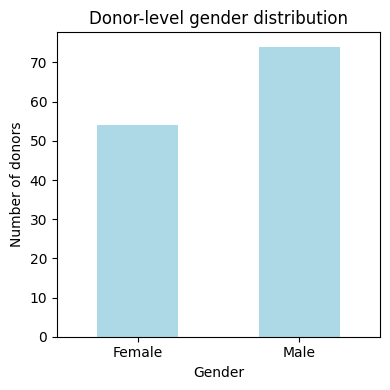

In [12]:
gender_meta_df = adata.obs[["pica_id", "Child's sex"]].drop_duplicates()

gender_meta_df["Child's sex"].value_counts().sort_index().plot(
    kind="bar", color="lightblue", figsize=(4,4)
)
plt.title("Donor-level gender distribution")
plt.xlabel("Gender")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

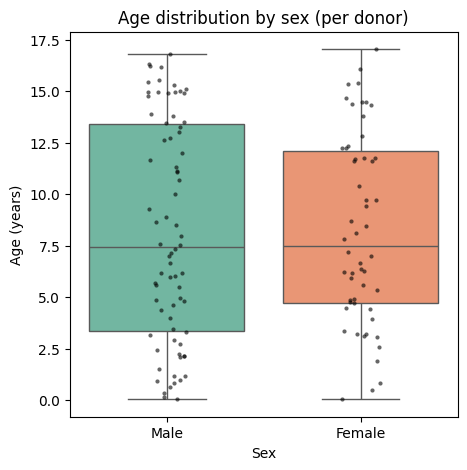

In [ ]:
meta_df = adata.obs[['pica_id', "Child's sex", "Age in years at the time of collection"]].drop_duplicates()

plt.figure(figsize=(5,5))
sns.boxplot(data=meta_df, x="Child's sex", y="Age in years at the time of collection", palette="Set2")
sns.stripplot(data=meta_df, x="Child's sex", y="Age in years at the time of collection", color="k", size=3, alpha=0.6)
plt.title("Age distribution by sex (per donor)")
plt.ylabel("Age (years)")
plt.xlabel("Sex")
plt.show()

In [13]:
adata.obs = adata.obs.applymap(
    lambda x: str(x) if not isinstance(x, (int, float, str)) else x
)

In [ ]:
adata.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_combined_annot_meta.h5ad", compression="gzip")

: 

### clean up age

In [2]:
adata_age=sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_combined_annot_meta.h5ad")

KeyboardInterrupt: 

In [ ]:
adata_age.obs.groupby("pica_id")["Age in years at the time of collection"].unique()

pica_id
PICA0001     [2.09]
PICA0002    [15.09]
PICA0003     [0.83]
PICA0004     [3.46]
PICA0005      [9.3]
             ...   
PICA0164     [2.15]
PICA0166     [0.62]
PICA0168     [16.2]
PICA0169     [2.72]
PICA0173    [15.31]
Name: Age in years at the time of collection, Length: 128, dtype: object

In [ ]:
adata_age.obs["Age in years int"] = (
    adata_age.obs["Age in years at the time of collection"]
    .astype(float)
    .apply(np.floor)  
    .astype(int)
)

In [ ]:
adata_age.obs.groupby("pica_id")["Age in years int"].unique()

pica_id
PICA0001     [2]
PICA0002    [15]
PICA0003     [0]
PICA0004     [3]
PICA0005     [9]
            ... 
PICA0164     [2]
PICA0166     [0]
PICA0168    [16]
PICA0169     [2]
PICA0173    [15]
Name: Age in years int, Length: 128, dtype: object

In [ ]:
# Define bins and labels
bins = [0, 3, 6, 10, 14, 18]
labels = ["0–3", "4–6", "7–10", "11–14", "15–18"]

# Create new column for grouped ages
adata_age.obs["Age_group"] = pd.cut(
    adata_age.obs["Age in years int"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

In [ ]:
adata_age.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      200569
4–6      189321
7–10     129489
11–14    224933
15–18     78311
Name: count, dtype: int64

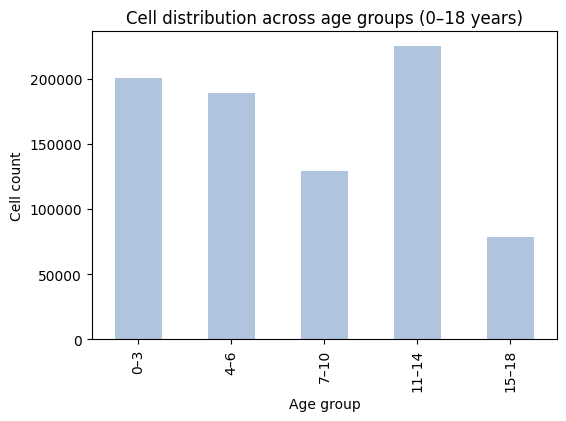

In [ ]:
adata_age.obs["Age_group"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4), color="lightsteelblue"
)
plt.title("Cell distribution across age groups (0–18 years)")
plt.xlabel("Age group")
plt.ylabel("Cell count")
plt.show()

In [ ]:
# create donor-level age group summary
age_meta_df = adata_age.obs[["pica_id", "Age_group"]].drop_duplicates()
age_meta_df["Age_group"].value_counts().sort_index()

Age_group
0–3      31
4–6      29
7–10     21
11–14    34
15–18    13
Name: count, dtype: int64

In [ ]:
age_meta_df["Age_group"].value_counts().sort_index().plot(
    kind="bar", color="salmon", figsize=(6,4)
)
plt.title("Donor-level age distribution")
plt.xlabel("Age group")
plt.ylabel("Number of donors")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
sc.pl.umap(adata_age, color=["Child's sex", "Age in years int", "Age_group"], wspace=0.4)

In [ ]:
adata_age.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_combined_annot_with_age.h5ad", compression="gzip")

### extract CD4 annotations

In [2]:
adata_subsets = sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_combined_annot_with_age.h5ad", backed='r')

In [3]:
adata_subsets.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      200569
4–6      189321
7–10     129489
11–14    224933
15–18     78311
Name: count, dtype: int64

In [4]:
cd4_terms = [
    "Naive/Central memory CD4 T cell",
    "CCR4+ CCR6+ memory CD4 T cell",
    "TOX+ CD4 T cell",
    "Tfh",
    "Tfh cell",
    "Th2 cell",
    "Th2-like T cell",
    "TIGIT+ TOX+ memory CD4 T cell",
    "CCR6+ memory CD4 T cell",
    "CCR6+ CD4 T cell",
    "CTLA4+ TOX+ CD4 T cell",
    "CCR4+ CD4 T cell",
    "Cytotoxic CD4 T cell",
    "Th2",
    "CCR4+ memory CD4 T cell",
    "Unknown CD4 T cell",
    "Innate-like CD4 T cell",
    "Regulatory T cell",
    "Treg",
]

cd8_terms = [
    "Naive/Central memory CD8 T cell",
    "CD8+ gdT cell",
    "GZMK+ CD8 T cell",
    "CD8 Temra",
    "TOX+ CD8 T cell",
    "CD27+ CCR7+ suppressed CD8 T cell",
    "CD27- CCR7- suppressed CD8 T cell",
    "CD27+ CCR7- suppressed CD8 T cell",
    "Suppressed CD8 T cell",
    "Inhibitory KIR+ CD8 T cell",
    "GZMK+ memory CD8 T cell",
    "Efector memory CD8 T cell",
    "CD8 TEM",
]

nk_terms = [
    "Cytotoxic NK cell",
    "Cytokine-producing NK cell",
    "Cytotoxic natural killer cell",
    "NK-like gdT cell",
    "NK-like gamma-delta T cell",
    "Innate-like T cell",
    "NKT",
    "ILC1",
    "ILC2",
    "ILC1/ILC2",
]

In [5]:
# default as 'Other'
adata_subsets.obs["major_lineage"] = "Other"

# assign CD4
adata_subsets.obs.loc[
    adata_subsets.obs["cell_type"].isin(cd4_terms),
    "major_lineage"
] = "CD4"

# assign CD8
adata_subsets.obs.loc[
    adata_subsets.obs["cell_type"].isin(cd8_terms),
    "major_lineage"
] = "CD8"

# assign NK
adata_subsets.obs.loc[
    adata_subsets.obs["cell_type"].isin(nk_terms),
    "major_lineage"
] = "NK"

In [6]:
print(adata_subsets.obs["major_lineage"].head())

20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGAAAGCGT      CD4
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACAATAG      CD4
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGACTTACG      CD4
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAAAGCTAGGTC    Other
20240918_WGS_20240924_sc_PICA0008-PICA0032_Pool_5_AAACCAGCAAAGGGGA      CD4
Name: major_lineage, dtype: object

In [9]:
save_dir = "/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
# CD4
cd4_idx = adata_subsets.obs.index[adata_subsets.obs["major_lineage"] == "CD4"]
sc.read_h5ad(adata_subsets.filename, backed="r")[cd4_idx, :].write_h5ad(
    save_dir + "PICA_Batch001-Batch007_cd4_combined_annot_with_age.h5ad",
    compression="gzip"
)

In [ ]:
# CD8
cd8_idx = adata_subsets.obs.index[adata_subsets.obs["major_lineage"] == "CD8"]
sc.read_h5ad(adata_subsets.filename, backed="r")[cd8_idx, :].write_h5ad(
    save_dir + "PICA_Batch001-Batch007_cd8_combined_annot_with_age.h5ad",
    compression="gzip"
)

In [ ]:
# NK
nk_idx = adata_subsets.obs.index[adata_subsets.obs["major_lineage"] == "NK"]
sc.read_h5ad(adata_subsets.filename, backed="r")[nk_idx, :].write_h5ad(
    save_dir + "PICA_Batch001-Batch007_nk_combined_annot_with_age.h5ad",
    compression="gzip"
)

#### run scvi for cd4

In [ ]:
adata_scvi_cd4 =sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age.h5ad")

In [ ]:
scvi.model.SCVI.setup_anndata(adata_scvi_cd4, layer="counts", batch_key="pica_id")

In [ ]:
model_cd4 = scvi.model.SCVI(adata_scvi_cd4, n_layers=2, n_latent=30, gene_likelihood="nb")

In [ ]:
model_cd4.train()

In [ ]:
adata_scvi_cd4.obsm["X_scVI"] = model_cd4.get_latent_representation()

#  latent representation 
sc.pp.neighbors(adata_scvi_cd4, use_rep="X_scVI")
sc.tl.umap(adata_scvi_cd4)


sc.pl.umap(adata_scvi_cd4, color=[ "pica_id", 'cell_type'], save="_scvi_integrated_umap.png")

In [ ]:
adata_scvi_cd4.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad", compression="gzip")

In [ ]:
sc.pl.umap(
    adata_scvi_cd4,
    color=["log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
    save="_scvi_qc.png"
)

#### convert to sce object

In [ ]:
import anndata2ri
import rpy2.robjects as robjects
from rpy2.robjects.conversion import localconverter

with localconverter(robjects.default_converter + anndata2ri.converter):
    sce = robjects.conversion.py2rpy(adata_scvi_cd4)

# Save the sce object in .rds file
robjects.globalenv["sce"] = sce
robjects.r("saveRDS(sce, file='{}')".format("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.sce.rds"))

#### run scvi for cd8

In [ ]:
adata_scvi_cd8 =sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age.h5ad")

In [ ]:
scvi.model.SCVI.setup_anndata(adata_scvi_cd8, layer="counts", batch_key="pica_id")

In [ ]:
model_cd8 = scvi.model.SCVI(adata_scvi_cd8, n_layers=2, n_latent=30, gene_likelihood="nb")

In [ ]:
model_cd8.train()

In [ ]:
adata_scvi_cd8.obsm["X_scVI"] = model_cd8.get_latent_representation()

#  latent representation 
sc.pp.neighbors(adata_scvi_cd8, use_rep="X_scVI")
sc.tl.umap(adata_scvi_cd8)


sc.pl.umap(adata_scvi_cd8, color=[ "pica_id", 'cell_type'], save="_scvi_integrated_umap.png")

In [ ]:
adata_scvi_cd8.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.h5ad", compression="gzip")

In [ ]:
sc.pl.umap(
    adata_scvi_cd8,
    color=["log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
    save="_scvi_qc.png"
)

#### convert to sce object

In [ ]:
import anndata2ri
import rpy2.robjects as robjects
from rpy2.robjects.conversion import localconverter

with localconverter(robjects.default_converter + anndata2ri.converter):
    sce = robjects.conversion.py2rpy(adata_scvi_cd8)

# Save the sce object in .rds file
robjects.globalenv["sce"] = sce
robjects.r("saveRDS(sce, file='{}')".format("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd8_combined_annot_with_age_scvi.sce.rds"))

#### run scvi for nk

In [ ]:
adata_scvi_nk =sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age.h5ad")

In [ ]:
scvi.model.SCVI.setup_anndata(adata_scvi_nk, layer="counts", batch_key="pica_id")

In [ ]:
model_nk = scvi.model.SCVI(adata_scvi_nk, n_layers=2, n_latent=30, gene_likelihood="nb")

In [ ]:
model_nk.train()

In [ ]:
adata_scvi_nk.obsm["X_scVI"] = model_nk.get_latent_representation()

#  latent representation 
sc.pp.neighbors(adata_scvi_nk, use_rep="X_scVI")
sc.tl.umap(adata_scvi_nk)


sc.pl.umap(adata_scvi_nk, color=[ "pica_id", 'cell_type'], save="_scvi_integrated_umap.png")

In [ ]:
adata_scvi_nk.write_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.h5ad", compression="gzip")

In [ ]:
sc.pl.umap(
    adata_scvi_nk,
    color=["log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
    save="_scvi_qc.png"
)

#### convert to sce object

In [ ]:
import anndata2ri
import rpy2.robjects as robjects
from rpy2.robjects.conversion import localconverter

with localconverter(robjects.default_converter + anndata2ri.converter):
    sce = robjects.conversion.py2rpy(adata_scvi_nk)

# Save the sce object in .rds file
robjects.globalenv["sce"] = sce
robjects.r("saveRDS(sce, file='{}')".format("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_nk_combined_annot_with_age_scvi.sce.rds"))